In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import torch.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import functional as TF


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from scipy.stats import t
import ast
from pathlib import Path

import statsmodels.api as sm
from statsmodels.formula.api import ols

In [2]:
def precision_recall_par_classe(conf_matrix):

    precisions = []
    recalls = []
    n_classes = len(conf_matrix)
    
    for i in range(n_classes):
        # True Positive
        tp = conf_matrix[i][i]

        # False Negative
        fn = sum(conf_matrix[i]) - tp

        # False Positive
        fp = sum(conf_matrix[j][i] for j in range(n_classes)) - tp

        precision = tp / (tp + fp)
        recall = tp / (tp + fn)

        precisions.append(precision)
        recalls.append(recall)
    
    return precisions, recalls

In [3]:
def plot_precision_recall_hitmap(cm_series, vmin, vmax):

    resultats = []

    for net_name, cm in cm_series.items():
        precision, recall = precision_recall_par_classe(cm)

        for classe in range(10):
            resultats.append({
                "Modele": net_name,
                "Classe": classe,
                "Precision": precision[classe],
                "Recall": recall[classe]
            })

    df = pd.DataFrame(resultats)

    pivot_precision = df.pivot(
        index="Classe",
        columns="Modele",
        values="Precision"
    )

    pivot_recall = df.pivot(
        index="Classe",
        columns="Modele",
        values="Recall"
    )


    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ----- Precision -----
    im2 = axes[0].imshow(pivot_precision, vmin=vmin, vmax=vmax, aspect='auto')
    fig.colorbar(im2, ax=axes[0], label="Precision")

    axes[0].set_xticks(range(len(pivot_precision.columns)))
    axes[0].set_xticklabels(
        pivot_precision.columns,
        rotation=60
    )

    axes[0].set_yticks(range(10))
    axes[0].set_yticklabels(range(10))

    axes[0].set_xlabel("Modèles")
    axes[0].set_ylabel("Classe")
    axes[0].set_title("Precision par classe et par modèle")

    # ----- Recall -----
    im1 = axes[1].imshow(pivot_recall, vmin=vmin, vmax=vmax, aspect='auto')
    fig.colorbar(im1, ax=axes[1], label="Recall")

    axes[1].set_xticks(range(len(pivot_recall.columns)))
    axes[1].set_xticklabels(
        pivot_recall.columns,
        rotation=60
    )

    axes[1].set_yticks(range(10))
    axes[1].set_yticklabels(range(10))

    axes[1].set_xlabel("Modèles")
    axes[1].set_ylabel("Classe")
    axes[1].set_title("Recall par classe et par modèle")

    # Ajuste automatiquement l'espacement
    plt.tight_layout()

    # Affichage final
    plt.show()

ETUDE DE ROBUSTESSE

PARTIE 1 : SANS DATA AUGMENTATION

TRANSFORMATION APPLIQUE AU DATASET DE TEST : ROTATION

In [4]:
df2 = pd.read_json("configurations/accuracies_rotation_robustesse.json")

In [5]:
df2 = df2.T

In [6]:
df2

,0,5,10,15,20,25,30,35
network3,99.32,99.20,98.99,98.64,98.16,97.26,95.85,93.87
CNN_with_BN,99.38,99.37,98.98,98.72,98.08,96.82,94.90,92.99
dropout_CNN,99.37,99.27,99.03,98.71,98.22,97.28,95.96,93.71
dropout_lenet5,99.19,99.13,99.08,98.67,98.10,97.19,95.57,93.43
lenet5,99.25,99.15,98.86,98.54,98.00,96.97,95.41,92.94
lenet4,99.09,98.93,98.72,98.32,97.72,96.73,95.26,93.35
simplified_lenet5,98.89,98.81,98.55,98.06,97.32,96.36,95.08,92.73
dilated_lenet5,98.94,98.83,98.54,98.04,97.30,95.99,93.69,90.95
lenet1,98.44,98.20,97.95,97.39,96.58,95.11,93.01,90.07
400-300-10,98.34,98.31,97.82,97.06,95.94,94.13,91.64,87.77


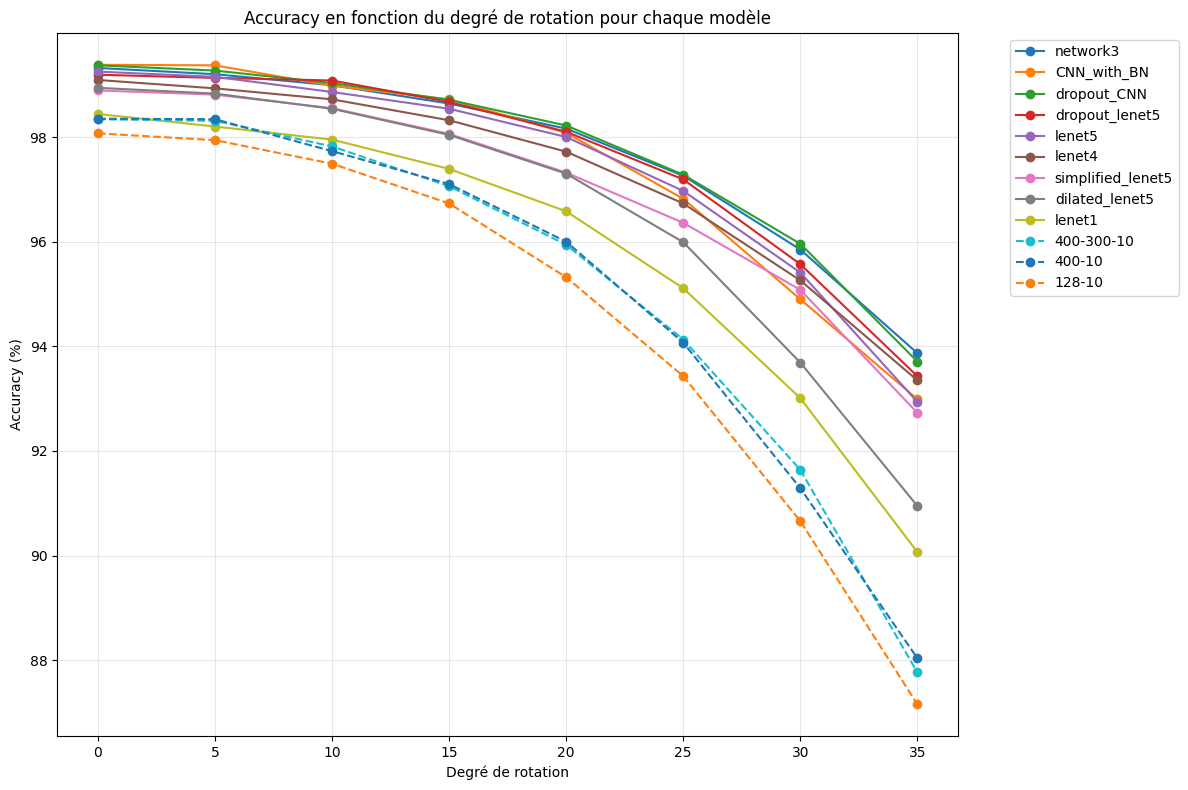

In [7]:
dashed_models = ['400-300-10', '400-10', '128-10']

plt.figure(figsize=(12, 8))
angles = df2.columns.astype(float)

for model in df2.index:
    linestyle = '--' if model in dashed_models else '-'
    plt.plot(
        angles,
        df2.loc[model].values,
        marker='o',
        linestyle=linestyle,
        label=model
    )

plt.xlabel('Degré de rotation')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy en fonction du degré de rotation pour chaque modèle')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

TRANSFORMATION APPLIQUE AU DATASET DE TEST : TRANSLATION

In [8]:
df3 = pd.read_json("configurations/accuracies_translation_robustesse.json", convert_axes=False)

In [9]:
df3 = df3.T

In [10]:
df3

,0.0,0.02,0.04,0.06,0.08,0.1,0.12,0.14
network3,99.32,99.24,98.77,97.79,95.98,91.94,86.74,79.07
CNN_with_BN,99.38,99.26,98.86,98.07,96.35,92.10,86.92,79.16
dropout_CNN,99.37,99.32,98.59,97.51,94.88,89.96,84.23,75.72
dropout_lenet5,99.19,99.11,98.78,98.10,96.45,92.92,88.22,80.75
lenet5,99.25,99.18,98.53,97.43,94.96,90.64,85.16,76.88
lenet4,99.09,98.91,98.35,97.31,94.93,90.56,84.94,76.16
simplified_lenet5,98.89,98.77,98.19,97.04,94.65,89.88,84.41,76.10
dilated_lenet5,98.94,98.71,97.89,96.82,94.27,89.47,84.27,76.20
lenet1,98.44,98.41,97.85,96.78,94.40,90.34,85.89,78.99
400-300-10,98.34,97.97,96.39,93.00,86.65,78.13,69.24,58.90


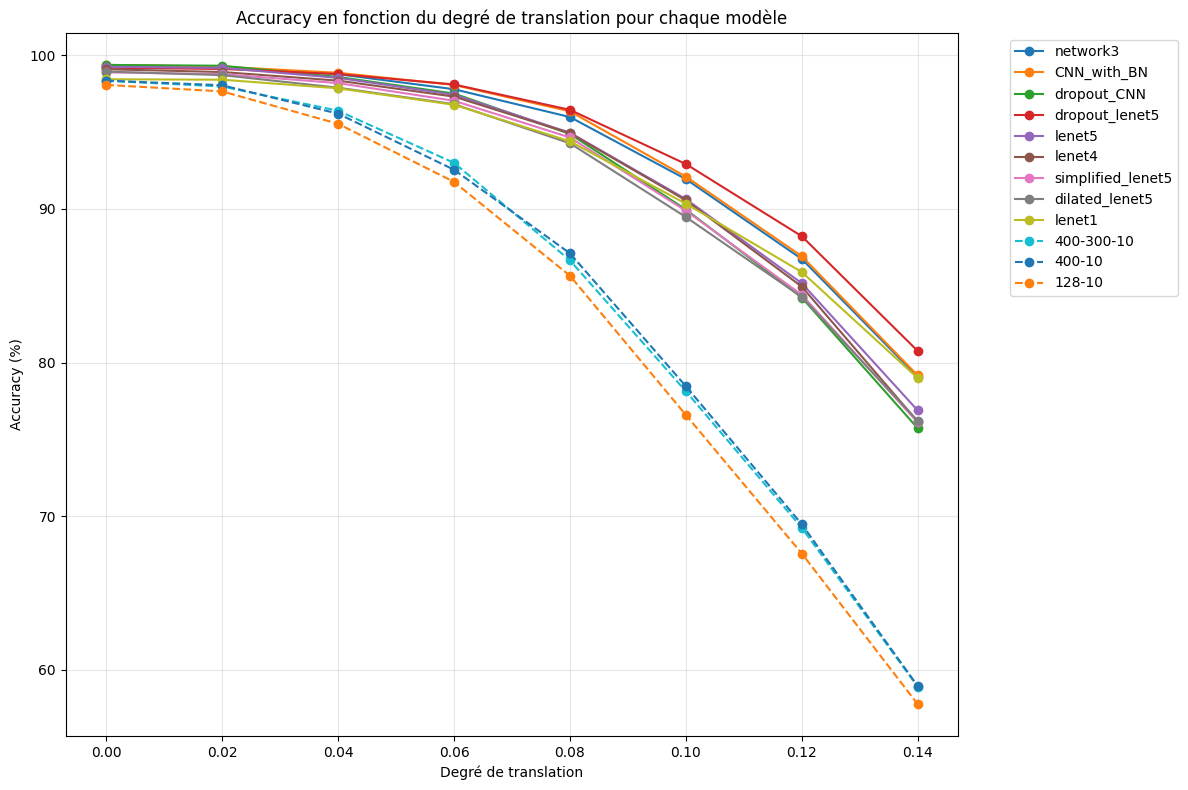

In [11]:
dashed_models = ['400-300-10', '400-10', '128-10']

plt.figure(figsize=(12, 8))
angles = df3.columns.astype(float)

for model in df3.index:
    linestyle = '--' if model in dashed_models else '-'
    plt.plot(
        angles,
        df3.loc[model].values,
        marker='o',
        linestyle=linestyle,
        label=model
    )

plt.xlabel('Degré de translation')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy en fonction du degré de translation pour chaque modèle')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

TRANSFORMATION APPLIQUE AU DATASET DE TEST : ROTATION + TRANSLATION

In [12]:
df = pd.read_csv("results/results_train_save_test_list_affine.csv")
df

,train_data_time,test_data_time,net_name,network_time,epoch,lr,train_time,forward_time,load_time,accuracy,confusion_matrix
0,0.024793,0.005400,network3,0.005161,29,0.005-0.005,1046.175236,0.561456,2.026303,96.89,"[[970, 1, 1, 0, 2, 1, 2, 1, 0, 2], [0, 1122, 7..."
1,0.027259,0.006433,CNN_with_BN,0.012013,29,0.005-0.005,1212.311395,0.844568,2.277236,97.19,"[[968, 0, 3, 1, 1, 1, 0, 5, 1, 0], [0, 1128, 3..."
2,0.027271,0.005631,dropout_CNN,0.001325,24,0.005-0.005,637.811553,0.354375,2.271898,96.87,"[[968, 0, 2, 1, 1, 1, 3, 2, 2, 0], [1, 1118, 5..."
3,0.029273,0.004951,dropout_lenet5,0.000914,25,0.005-0.005,618.757518,0.294635,2.502546,96.60,"[[958, 0, 0, 1, 1, 0, 10, 5, 2, 3], [0, 1118, ..."
4,0.026674,0.005265,lenet5,0.000892,27,0.005-0.005,609.557229,0.278647,2.199185,97.33,"[[967, 0, 3, 0, 0, 0, 5, 3, 2, 0], [0, 1129, 1..."
5,0.025996,0.005154,lenet4,0.000729,24,0.005-0.005,521.830653,0.242615,2.283361,97.19,"[[961, 0, 2, 2, 0, 1, 5, 4, 4, 1], [1, 1120, 2..."
6,0.026662,0.005540,simplified_lenet5,0.000629,18,0.005-0.005,358.147151,0.237627,1.954775,94.22,"[[950, 0, 9, 2, 1, 6, 8, 3, 1, 0], [0, 1118, 5..."
7,0.027712,0.005365,dilated_lenet5,0.000841,29,0.005-0.005,705.867570,0.268659,2.228561,97.03,"[[970, 0, 0, 0, 0, 1, 3, 3, 1, 2], [0, 1131, 0..."
8,0.028192,0.005635,lenet1,0.000512,17,0.005-0.005,475.377324,0.193495,3.023455,93.33,"[[940, 2, 5, 4, 1, 3, 12, 4, 8, 1], [0, 1111, ..."
9,0.025590,0.005503,400-300-10,0.002325,29,0.005-0.005,645.989424,0.088244,2.912227,95.63,"[[964, 0, 1, 0, 1, 4, 6, 2, 1, 1], [1, 1121, 3..."


In [13]:
df_test_list_affine = pd.read_csv("results/results_test_list_affine.csv")

In [14]:
df_test_list_affine

,net_name,network_time,test_data_time,forward_time,load_time,accuracy,confusion_matrix
0,network3,0.004432,1.333618,0.472952,0.092747,99.32,"[[978, 0, 0, 0, 0, 0, 1, 1, 0, 0], [0, 1132, 1..."
1,CNN_with_BN,0.008309,1.374330,0.758628,0.106080,99.38,"[[979, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1134, 0..."
2,dropout_CNN,0.001333,1.459467,0.254791,0.086268,99.37,"[[975, 0, 1, 0, 0, 0, 3, 1, 0, 0], [0, 1133, 0..."
3,dropout_lenet5,0.000912,1.524061,0.184439,0.079551,99.19,"[[978, 0, 0, 0, 0, 0, 0, 1, 1, 0], [0, 1131, 0..."
4,lenet5,0.000999,1.545873,0.176417,0.082790,99.25,"[[975, 0, 0, 0, 0, 0, 2, 2, 1, 0], [1, 1130, 0..."
...,...,...,...,...,...,...,...
91,dilated_lenet5,0.000704,1.445321,0.173042,0.071046,50.72,"[[366, 31, 109, 22, 50, 82, 121, 58, 74, 67], ..."
92,lenet1,0.000409,1.655863,0.109694,0.064121,54.87,"[[437, 66, 82, 32, 91, 63, 75, 41, 41, 52], [1..."
93,400-300-10,0.001664,1.287461,0.047656,0.062442,36.18,"[[271, 34, 120, 108, 71, 97, 70, 60, 72, 77], ..."
94,400-10,0.001211,1.280527,0.034314,0.064102,36.09,"[[261, 67, 134, 100, 62, 104, 66, 82, 47, 57],..."


In [15]:
nb_nets = 12
accuracy_list = [df_test_list_affine["accuracy"].iloc[i * nb_nets : (i + 1) * nb_nets].tolist() for i in range(8)]

df_accuracies_affine = pd.DataFrame(accuracy_list).T

model_names = df_test_list_affine["net_name"].iloc[:nb_nets].tolist()
df_accuracies_affine.index = model_names
df_accuracies_affine.index.name = "net_name"

df_accuracies_affine.columns = [(round(i * 0.03, 2), i * 5) for i in range(df_accuracies_affine.shape[1])]


In [16]:
df_accuracies_affine

,"(0.0, 0)","(0.03, 5)","(0.06, 10)","(0.09, 15)","(0.12, 20)","(0.15, 25)","(0.18, 30)","(0.21, 35)"
net_name,,,,,,,,
network3,99.32,99.24,98.49,96.11,89.51,78.70,66.57,53.36
CNN_with_BN,99.38,99.32,98.52,96.18,89.13,77.63,65.33,52.60
dropout_CNN,99.37,99.27,98.54,95.68,88.03,76.59,63.44,51.16
dropout_lenet5,99.19,99.10,98.53,96.31,90.83,81.38,69.42,56.89
lenet5,99.25,99.15,98.07,95.50,87.58,78.17,64.02,52.06
lenet4,99.09,98.94,97.94,95.24,88.14,77.49,65.11,52.42
simplified_lenet5,98.89,98.86,98.04,94.98,88.48,77.68,63.96,52.11
dilated_lenet5,98.94,98.82,97.98,93.96,86.90,75.80,63.74,50.72
lenet1,98.44,98.27,97.27,94.30,87.64,78.32,66.68,54.87


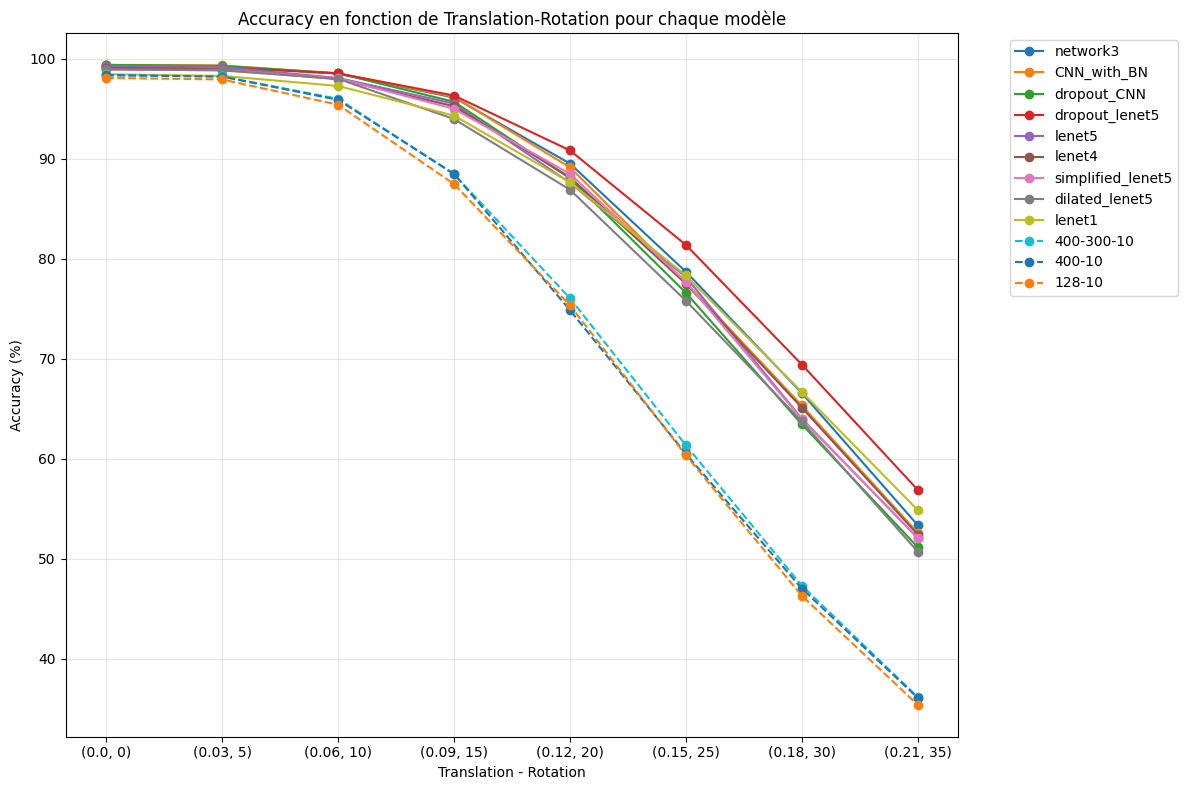

In [17]:
plt.figure(figsize=(12, 8))
tuples = [str(t) for t in df_accuracies_affine.columns]
for model in df_accuracies_affine.index:
    linestyle = '--' if model in dashed_models else '-'
    plt.plot(tuples, df_accuracies_affine.loc[model].values, marker='o', linestyle=linestyle, label=model)

plt.xlabel('Translation - Rotation')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy en fonction de Translation-Rotation pour chaque modèle')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

PRECISION ET RAPPEL EN FONCTION DES TRANSFORMATIONS APPLIQUES AU DATASET DE TEST

In [18]:
df_test_list_affine = df_test_list_affine.set_index("net_name")
df_test_list_affine["confusion_matrix"] = df_test_list_affine["confusion_matrix"].apply(ast.literal_eval)

In [19]:
nb_nets = 12
list_df_affine = []
for i in range (8):
    list_df_affine.append(df_test_list_affine.iloc[i*nb_nets : (i+1)*nb_nets])

transformations : (0.0, 0)


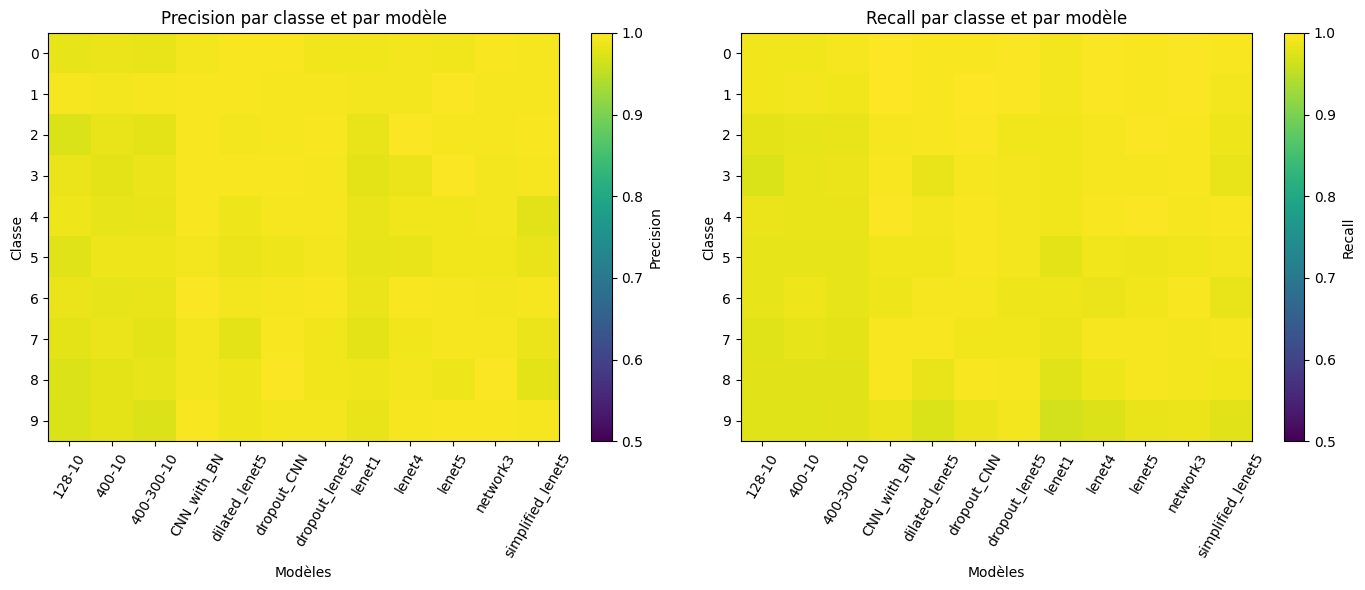

In [20]:
print(f"transformations : {df_accuracies_affine.columns[0]}")
plot_precision_recall_hitmap(list_df_affine[0]["confusion_matrix"], vmin = 0.5, vmax = 1.0)

transformations : (0.12, 20)


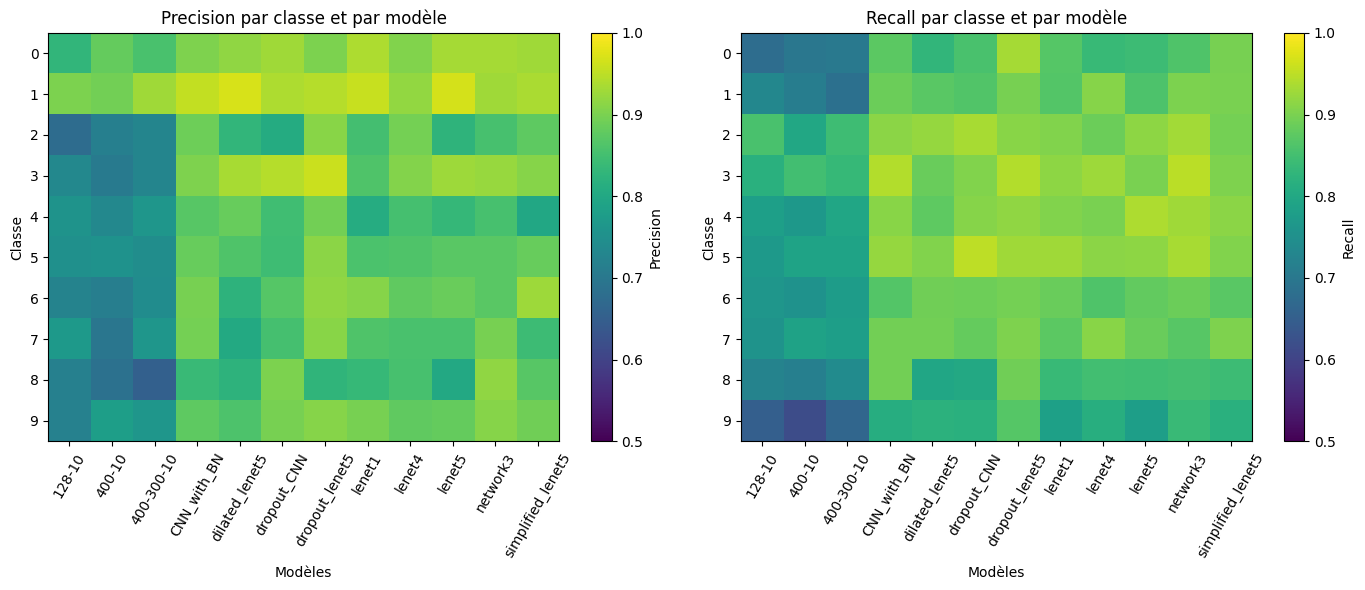

In [21]:
print(f"transformations : {df_accuracies_affine.columns[4]}")
plot_precision_recall_hitmap(list_df_affine[4]["confusion_matrix"], vmin = 0.5, vmax = 1.0)

transformations : (0.21, 35)


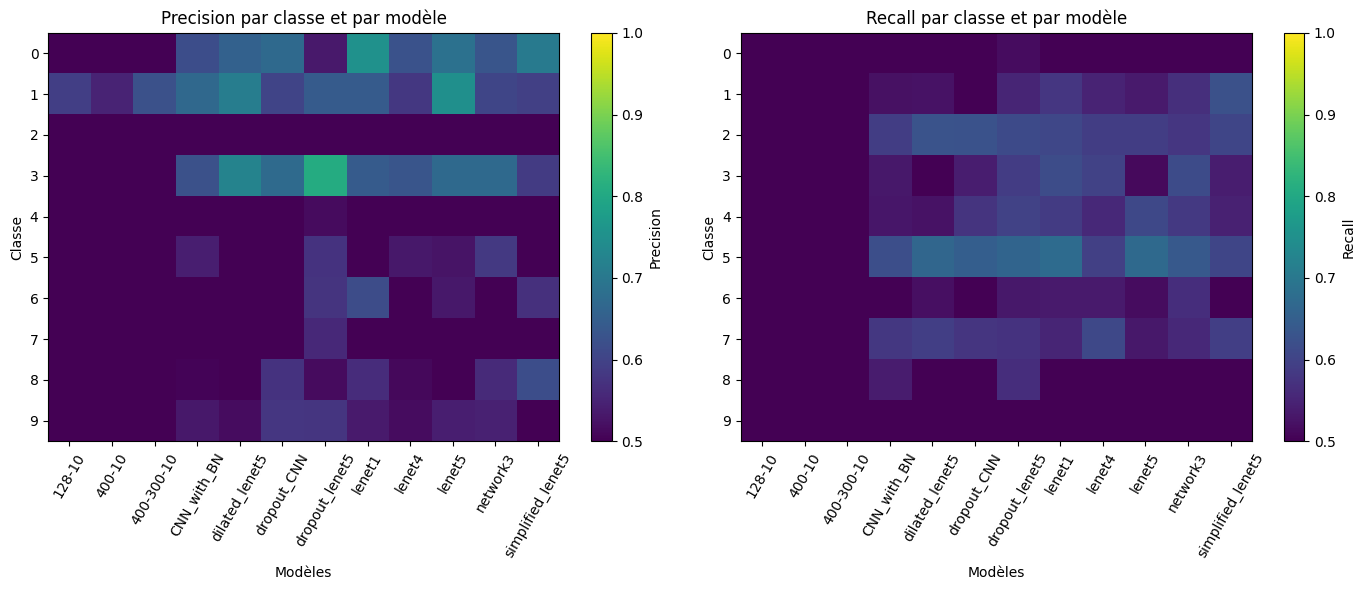

In [22]:
print(f"transformations : {df_accuracies_affine.columns[7]}")
plot_precision_recall_hitmap(list_df_affine[7]["confusion_matrix"], vmin = 0.5, vmax = 1.0)

PARTIE 2 : AVEC DATA AUGMENTATION

In [23]:
df_test_list_affine_trained = pd.read_csv("results/results_test_list_affine_trained.csv")

In [24]:
df_test_list_affine_trained

,net_name,network_time,test_data_time,forward_time,load_time,accuracy,confusion_matrix
0,network3,0.004776,1.328456,0.481379,0.096215,98.57,"[[972, 0, 1, 0, 0, 0, 4, 0, 3, 0], [0, 1127, 3..."
1,CNN_with_BN,0.011872,1.316748,0.768479,0.103757,98.95,"[[978, 0, 1, 0, 0, 0, 1, 0, 0, 0], [0, 1130, 4..."
2,dropout_CNN,0.001178,1.465383,0.263536,0.087238,98.38,"[[970, 0, 4, 0, 2, 0, 2, 0, 2, 0], [1, 1116, 4..."
3,dropout_lenet5,0.000913,1.477864,0.184116,0.074663,97.98,"[[974, 0, 0, 0, 0, 0, 4, 1, 1, 0], [2, 1122, 4..."
4,lenet5,0.000725,1.531955,0.189409,0.080913,98.80,"[[971, 0, 3, 0, 1, 0, 4, 0, 0, 1], [0, 1129, 1..."
...,...,...,...,...,...,...,...
91,dilated_lenet5,0.000889,1.501634,0.169651,0.069887,97.36,"[[971, 0, 0, 0, 0, 1, 2, 5, 1, 0], [0, 1129, 1..."
92,lenet1,0.000462,1.669601,0.134018,0.082722,94.28,"[[950, 0, 3, 3, 2, 1, 8, 3, 8, 2], [3, 1111, 4..."
93,400-300-10,0.002207,1.289230,0.051650,0.067859,96.16,"[[968, 0, 1, 1, 0, 2, 5, 0, 2, 1], [0, 1120, 2..."
94,400-10,0.001644,1.294133,0.036721,0.063835,93.48,"[[955, 0, 4, 0, 2, 5, 3, 2, 9, 0], [0, 1111, 3..."


In [25]:
nb_nets = 12
accuracy_list = [df_test_list_affine_trained["accuracy"].iloc[i * nb_nets : (i + 1) * nb_nets].tolist() for i in range(8)]

df_accuracies_affine_trained = pd.DataFrame(accuracy_list).T

model_names = df_test_list_affine_trained["net_name"].iloc[:nb_nets].tolist()
df_accuracies_affine_trained.index = model_names
df_accuracies_affine_trained.index.name = "net_name"

df_accuracies_affine_trained.columns = [(round(i * 0.03, 2), i * 5) for i in range(df_accuracies_affine_trained.shape[1])]

In [26]:
df_accuracies_affine_trained

,"(0.0, 0)","(0.03, 5)","(0.06, 10)","(0.09, 15)","(0.12, 20)","(0.15, 25)","(0.18, 30)","(0.21, 35)"
net_name,,,,,,,,
network3,98.57,98.52,98.43,98.38,98.35,98.11,97.97,97.47
CNN_with_BN,98.95,98.85,98.76,98.70,98.69,98.48,98.27,97.83
dropout_CNN,98.38,98.29,98.19,97.93,98.02,97.91,97.54,96.98
dropout_lenet5,97.98,97.82,97.81,97.88,97.70,97.54,97.66,96.88
lenet5,98.80,98.68,98.57,98.69,98.33,98.43,98.19,97.70
lenet4,98.20,98.18,98.26,98.03,97.98,97.72,97.63,97.11
simplified_lenet5,97.36,97.22,96.73,96.65,96.53,96.28,95.87,94.87
dilated_lenet5,98.36,98.17,98.05,98.13,97.95,97.99,97.48,97.36
lenet1,96.52,96.37,96.20,96.08,95.90,95.59,95.29,94.28


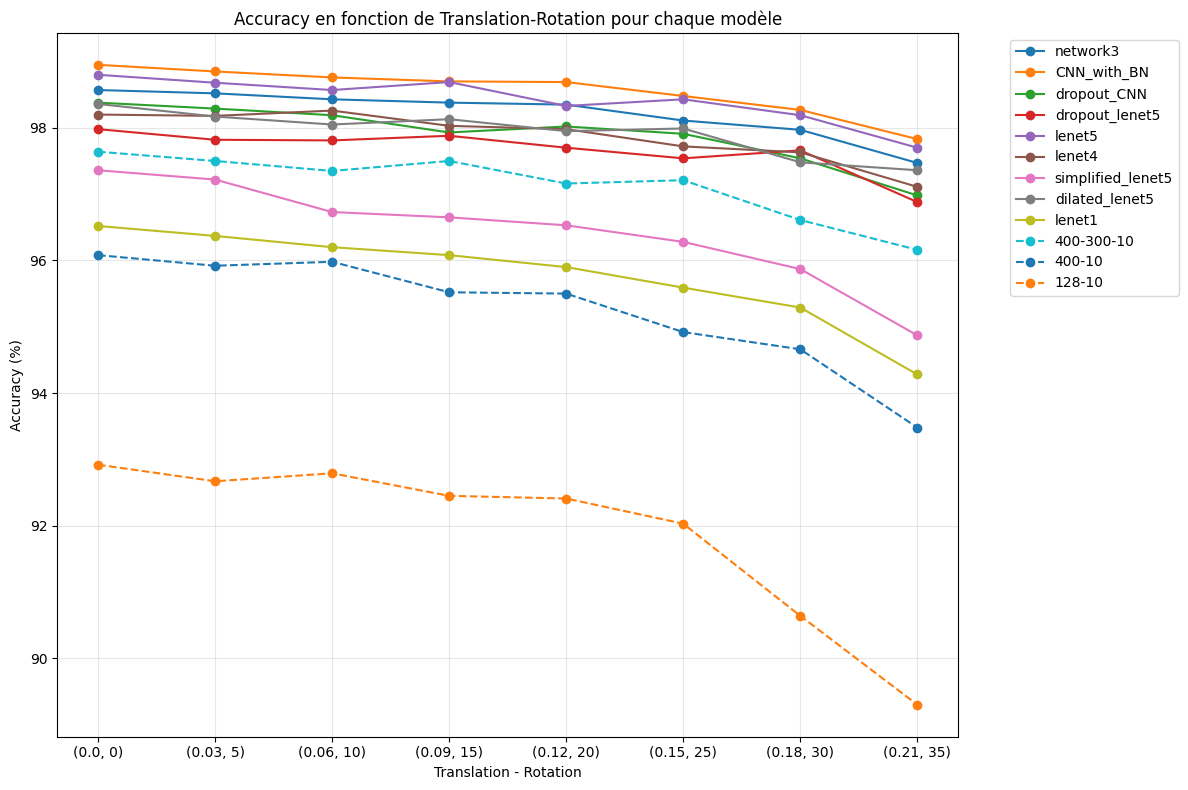

In [27]:
plt.figure(figsize=(12, 8))
tuples = [str(t) for t in df_accuracies_affine_trained.columns]
for model in df_accuracies_affine_trained.index:
    linestyle = '--' if model in dashed_models else '-'
    plt.plot(tuples, df_accuracies_affine_trained.loc[model].values, marker='o', linestyle=linestyle, label=model)

plt.xlabel('Translation - Rotation')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy en fonction de Translation-Rotation pour chaque modèle')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
df_test_list_affine_trained["confusion_matrix"] = df_test_list_affine_trained["confusion_matrix"].apply(ast.literal_eval)
df_test_list_affine_trained = df_test_list_affine_trained.set_index("net_name")

In [29]:
nb_nets = 12
df_list = []
for i in range (8):
    df_list.append(df_test_list_affine_trained.iloc[i*nb_nets : (i+1)*nb_nets])

transformations : (0.0, 0)


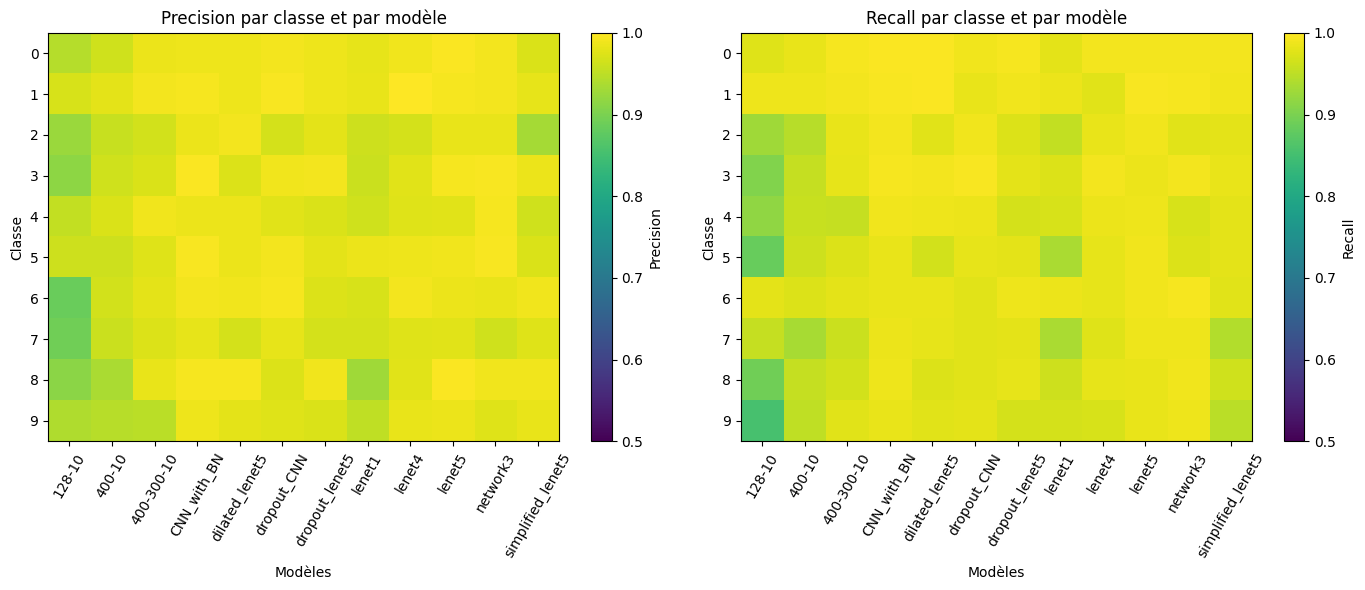

In [30]:
print(f"transformations : {df_accuracies_affine_trained.columns[0]}")
plot_precision_recall_hitmap(df_list[0]["confusion_matrix"], vmin = 0.5, vmax = 1.0)

transformations : (0.12, 20)


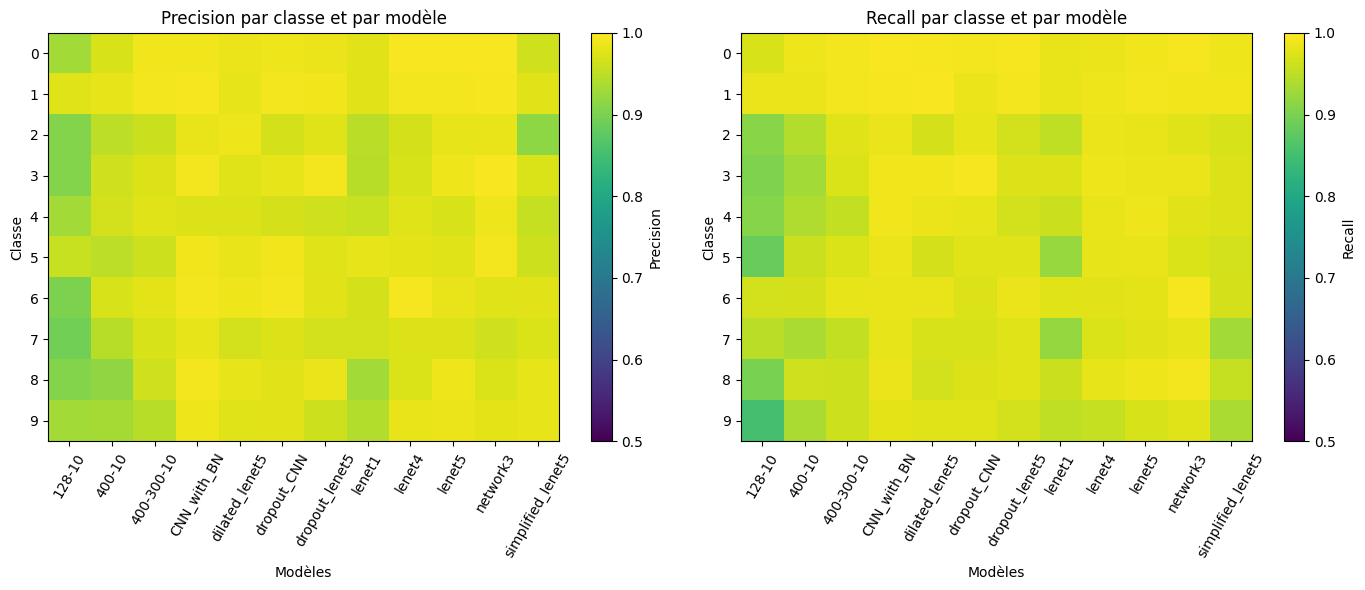

In [31]:
print(f"transformations : {df_accuracies_affine_trained.columns[4]}")
plot_precision_recall_hitmap(df_list[4]["confusion_matrix"], vmin = 0.5, vmax = 1.0)

transformations : (0.21, 35)


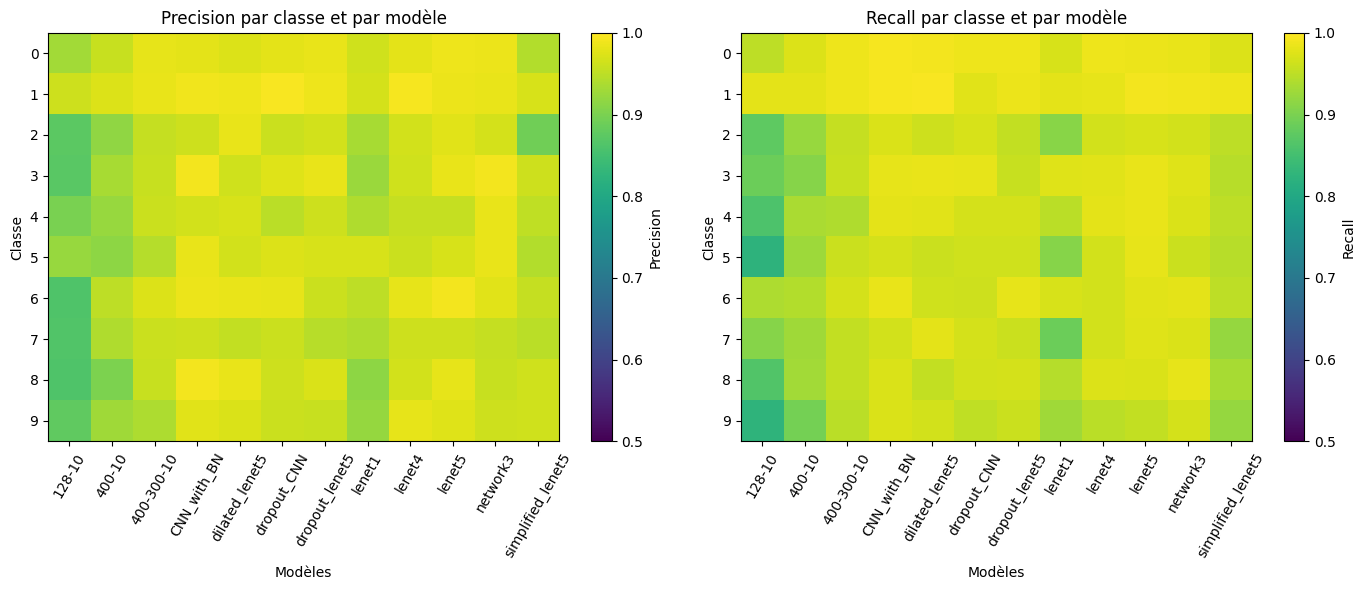

In [32]:
print(f"transformations : {df_accuracies_affine_trained.columns[7]}")
plot_precision_recall_hitmap(df_list[7]["confusion_matrix"], vmin = 0.5, vmax = 1.0)